# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# importar librerías

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv ('/datasets/users_latam.csv') #completa el código
usage = pd.read_csv ('/datasets/usage.csv') #completa el código

In [3]:
plans.head(5)# mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
users.head(5) # mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
usage.head(5) # mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:



# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users",users.shape)
print("usage",usage.shape)




plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
#al revisar la estructura de los database, vamos a realizar una limpieza DB Plan se encuentra bien no es necesario hacer nada
# Users, ciudad "?" hay que modificarlo, edad(-999 )no es posible, 

In [7]:
print("Info Plans")
plans.info()
# inspección de plans con .info()

Info Plans
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
print("Info Users")
users.info() # inspección de users con .info()

Info Users
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
print("Info Usage")
usage.info() # inspección de usage con .info()

Info Usage
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [12]:
# cantidad de nulos para users
print('Cantidad de valores nulos')
print(users.isna().sum())
print('Proporción de valores nulos')
print(users.isna().mean()*100)

Cantidad de valores nulos
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
Proporción de valores nulos
user_id        0.000
first_name     0.000
last_name      0.000
age            0.000
city          11.725
reg_date       0.000
plan           0.000
churn_date    88.350
dtype: float64


In [13]:
print('Cantidad de valores nulos')
print(usage.isna().sum())
print('Proporción de valores nulos')
print(usage.isna().mean()*100)# cantidad de nulos para usage

Cantidad de valores nulos
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
Proporción de valores nulos
id           0.000
user_id      0.000
type         0.000
date         0.125
duration    55.190
length      44.740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

**Análisis de columnas con valores faltantes:**

-churn_date **(88.35% nulos)**: Presenta una proporción muy alta de nulos, pero en este contexto es información valiosa. **Acción: Ignorar/Mantener, ya que los nulos indican que el usuario es un cliente activo.**

-city **(11.72% nulos)**: Se encuentra en el rango de investigación. **Acción: Investigar e imputar, ya que la proporción es significativa y necesitamos saber de dónde son los usuarios para el análisis regional.**

-duration **(55.19%) y length (44.74%)**: Tienen una alta proporción de nulos que parece ser MAR (Missing At Random). **Acción: Mantener como nulos, ya que dependen del tipo de registro (type); no se pueden imputar porque una llamada no genera mensajes y viceversa.**

date en usage **(0.12% nulos)**: Es una cantidad mínima de datos faltantes. **Acción: Eliminar o dejar como nulos, ya que al ser menos del 5% no afectan el volumen total del análisis de 40,000 registros.**



💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [20]:
# explorar columnas numéricas de users
print("Estadisticas de Users (age):")
print(users[['age','user_id']].describe())

Estadisticas de Users (age):
               age       user_id
count  4000.000000   4000.000000
mean     33.739750  11999.500000
std     123.232257   1154.844867
min    -999.000000  10000.000000
25%      32.000000  10999.750000
50%      47.000000  11999.500000
75%      63.000000  12999.250000
max      79.000000  13999.000000


- La columna `user_id` ...Son los números de identificación de los clientes. Todos son números positivos y se ven bien para conectar las tablas.
- La columna `age` ...Tiene un error: el valor -999. Es un valor falso que debemos quitar para que no arruine nuestros cálculos de edad

In [21]:

# explorar columnas numéricas de usage
print("Estadisticas de Usage (id,user_id,duration y length):")
print(usage[['id','user_id','duration','length']].describe())


Estadisticas de Usage (id,user_id,duration y length):
                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000



- Las columnas `id` y `user_id` Los números de identificación van del 1 al 40,000 y los números de cliente están entre el 10,000 y el 13,999. No hay números negativos ni errores, así que todo está bien etiquetado
- Las columnas `duration` y `length: Muestran que no hay tiempos ni mensajes negativos (el mínimo es 0). Pero, hay alguien que mandó 1,490 mensajes (el máximo de length). Ese es un valor muy alto (un outlier) que debemos revisar después, porque el promedio es de solo 52.



In [23]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"--Datos en {col}--")
    print(users[col].value_counts())
    print("\n")


--Datos en city--
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64


--Datos en plan--
Basico     2595
Premium    1405
Name: plan, dtype: int64




- La columna `city` Vemos que la mayoría de tus usuarios están en Bogotá (808) y CDMX (730).

El problema: Aparece el signo ? con 96 personas. Esas son las 96 personas de las que no sabemos dónde viven.

- La columna `plan` 2,595 personas en el plan Básico y 1,405 en el Premium. No hay nombres raros ni errores.

In [24]:
# explorar columna categórica de usage
usage['type'].value_counts() # completa el código

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` hay dos tipos de uso: text (22,092) y call (17,908). Los datos están bien etiquetados y no hay categorías extrañas. Esto confirma que los usuarios mandan más mensajes de los que hablan por teléfono.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 
**En la tabla users**: Encontré el valor -999 en la columna de edad (age) y el signo "?" en la columna de ciudad (city).

**En la tabla usage**: Todo se ve bien, no hay números negativos en las llamadas o mensajes.

- ¿Qué acción tomarías?

**Para la edad (age)**: Voy a quitar ese -999 y poner en su lugar la mediana.

**Para la ciudad (city)**: Cambiaré los "?" por un valor que la computadora entienda como "vacío" (NaN).

**Para las fechas**: Las convertiremos de "dibujo/texto" a "calendario real" para poder saber exactamente en qué mes del 2024 hicieron sus llamadas.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [28]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'],errors='coerce')
# completa el código

In [29]:

# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'],errors='coerce') # completa el código


In [30]:
# Revisar los años presentes en `reg_date` de users
print("Años en reg_date (Users):")
print(users['reg_date'].dt.year.value_counts())

Años en reg_date (Users):
2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64


En `reg_date`, (2026) 40 registros con el año 2026. Como el proyecto dice que hasta el 2024, es imposible que alguien se haya registrado dentro de dos años. Esto es claramente un error de dedo o un fallo en el sistema que capturó los datos.

In [31]:
# Revisar los años presentes en `date` de usage

print("Años en date (Usage):")

print(usage['date'].dt.year.value_counts())

Años en date (Usage):
2024.0    39950
Name: date, dtype: int64


En `date`, 39,950 registros que ocurrieron exactamente en el año 2024.

Faltan 50 piezas: Al principio vimos que había 40,000 filas en total, pero aquí solo aparecen 39,950. Esas 50 filas que faltan son los valores nulos (NaN) que detectamos al inicio en la columna date.

Consistencia: A diferencia de la tabla de usuarios, aquí no hay  (ni 2022, ni 2026). Todo el consumo de llamadas y mensajes se concentra en el 2024.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
-Sí, encontré 40 registros con el año 2026. Como estamos analizando datos de 2024, estas fechas son "del futuro" y representan un error de captura.

-En la tabla usage: No hay años imposibles, todos los registros son del 2024. Sin embargo, detecté que faltan 50 fechas (nulos), lo cual es una cantidad muy pequeña.
  
**- ¿Qué harías con ellas?**
-Para los registros de 2026: Recomiendo corregirlos al año 2024 o investigarlos, ya que si los dejamos así, cualquier cálculo de "antigüedad del cliente" nos daría un número negativo y arruinaría el promedio.

-Para las fechas pasadas (2022-2023): Los mantendré tal cual, ya que nos indican que son clientes antiguos que siguen activos en 2024.

-Para los nulos en usage: Como son muy pocos (menos del 1%), podemos ignorarlos o eliminarlos, ya que no afectarán la tendencia general de consumo del año.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [32]:
# Reemplazar -999 por la mediana de age
age_mediana = users[users['age'] != -999]['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
print("Estadísticas de Age corregidas:")
users['age'].describe()

Estadísticas de Age corregidas:


count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [33]:
# Reemplazar ? por NA en city
import numpy as np
users['city'] = users['city'].replace('?', np.nan)

# Verificar cambios
print("\nConteo de nulos en City:")
print(users['city'].isna().sum())


Conteo de nulos en City:
565


In [36]:
#Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
print("\nAños presentes en reg_date después de limpiar:")
print(users['reg_date'].dt.year.value_counts(dropna=False))




Años presentes en reg_date después de limpiar:
2024.0    1330
2023.0    1316
2022.0    1314
NaN         40
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [37]:
# Verificación MAR en usage (Missing At Random) para duration
print("--- Datos faltantes por tipo de uso ---")
print(usage.groupby('type')[['duration', 'length']].apply(lambda x: x.isnull().sum()))


--- Datos faltantes por tipo de uso ---
      duration  length
type                  
call         0   17896
text     22076       0


In [38]:

# Verificación MAR en usage (Missing At Random) para length


print("\nMuestra de los primeros 5 registros de Usage:")


print(usage[['type', 'duration', 'length']].head())



Muestra de los primeros 5 registros de Usage:
   type  duration  length
0  call      0.09     NaN
1  text       NaN    39.0
2  text       NaN    36.0
3  call      1.53     NaN
4  call      4.84     NaN


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
-En las llamadas (call): Hay 17,896 registros. Todos tienen una duración, pero ninguno tiene longitud de texto (length).

-En los mensajes (text): Hay 22,076 registros. Todos tienen longitud de texto, pero ninguno tiene una duración (duration).

**¿Qué significa esto?**
Confirmamos que los valores nulos son MAR. El "vacío" no es un error de captura, sino que depende de la columna type:
-Una llamada telefónica no tiene caracteres (por eso length es nulo).
-Un mensaje de texto no se mide en minutos (por eso duration es nulo).

**He decidido dejar los valores como nulos (NaN).**

-Si pusiéramos un "0" en la duración de los mensajes, el promedio de tiempo que la gente pasa hablando por teléfono se vería mucho más bajo de lo que realmente es (sería una mentira estadística).

**Al dejarlos como nulos, las herramientas de análisis de Python ignorarán automáticamente los mensajes cuando calcules estadísticas de llamadas, y viceversa. Esto nos da resultados 100% reales.**

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [39]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
  'is_text':'sum',
    'is_call':'sum',
    'duration':'sum'
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
##Columnas auxiliares y Agrupación: 
#Creamos dos columnas nuevas que marcan con un 1 si el registro es un mensaje o una llamada. Al agrupar por user_id, simplemente sumamos esos unos y obtenemos el total histórico de actividad para cada cliente. Esto transforma una lista de miles de eventos en un resumen de una sola fila por usuario.


In [40]:

# Renombrar columnas
usage_agg.columns = ['user_id', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
# observar resultado
usage_agg.head(3)



,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [41]:

# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')

# Opcional: Llenar los vacíos con 0 para los usuarios sin actividad
user_profile[['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']] = user_profile[['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].fillna(0)
user_profile.head(5)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [42]:
# Resumen estadístico de las columnas numéricas

user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe()


,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000,4000.000000
mean,48.136000,5.523000,4.477000,23.311225
std,17.689919,2.359738,2.145139,18.169564
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.107500
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.412500
max,79.000000,17.000000,15.000000,155.690000


In [43]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

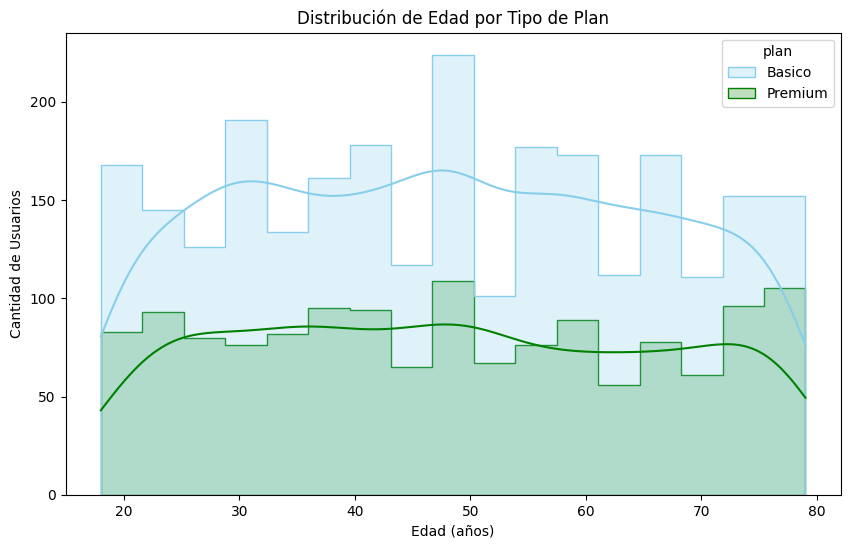

In [45]:
# Histograma para visualizar la edad (age)
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='age', hue='plan', element='step', palette=['skyblue', 'green'], kde=True)

# Títulos y etiquetas
plt.title('Distribución de Edad por Tipo de Plan')
plt.xlabel('Edad (años)')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights: 
- Distribución La edad tiene una distribución Uniforme. No hay un "pico" exagerado en una sola edad; tenemos usuarios de todas las edades (desde los 20 hasta los 80 años).

-Patrón por Plan: No existe un patrón de edad que defina el plan. Tanto el plan Básico como el Premium tienen usuarios jóvenes, adultos y mayores por igual. 

**Conclusión: La edad no es el factor que hace que un usuario elija un plan u otro.**

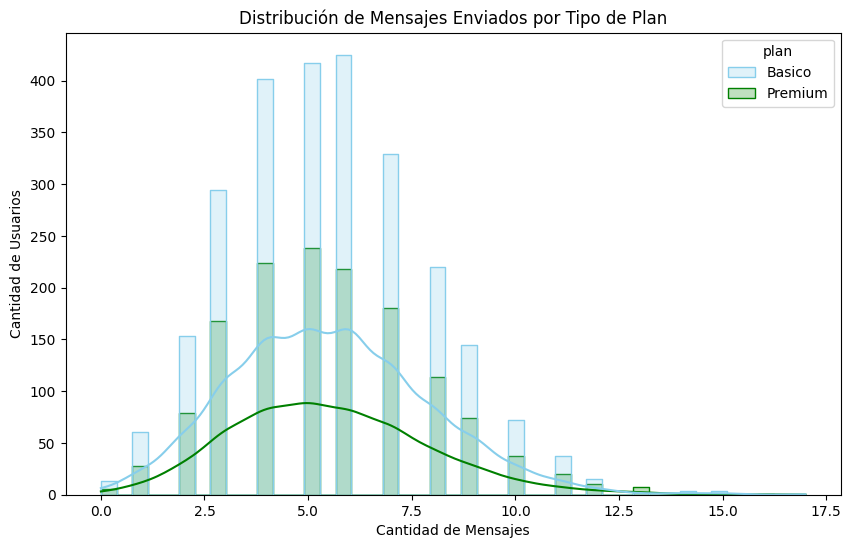

In [46]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', element='step', palette=['skyblue', 'green'], kde=True)

# Títulos y etiquetas
plt.title('Distribución de Mensajes Enviados por Tipo de Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Cantidad de Usuarios')
plt.show()


💡Insights: 
**Tipo de Distribución**: Es una distribución sesgada a la derecha. Esto significa que la mayoría de los usuarios envía pocos mensajes, pero hay un grupo pequeño de usuarios que envía muchos, estirando la "cola" del gráfico hacia la derecha.

Comparación por Plan:
-Plan Básico (Azul): Tiene una concentración mucho más alta de usuarios que envían cantidades bajas de mensajes (el pico más alto).
-Plan Premium (Verde): La curva es más baja y ancha. Esto indica que los usuarios Premium tienen un comportamiento más variado y se atreven a enviar más mensajes que los del plan Básico.

Conclusión: Los usuarios del plan Premium tienden a ser más activos enviando mensajes, mientras que los del plan Básico se mantienen en rangos más conservadores.

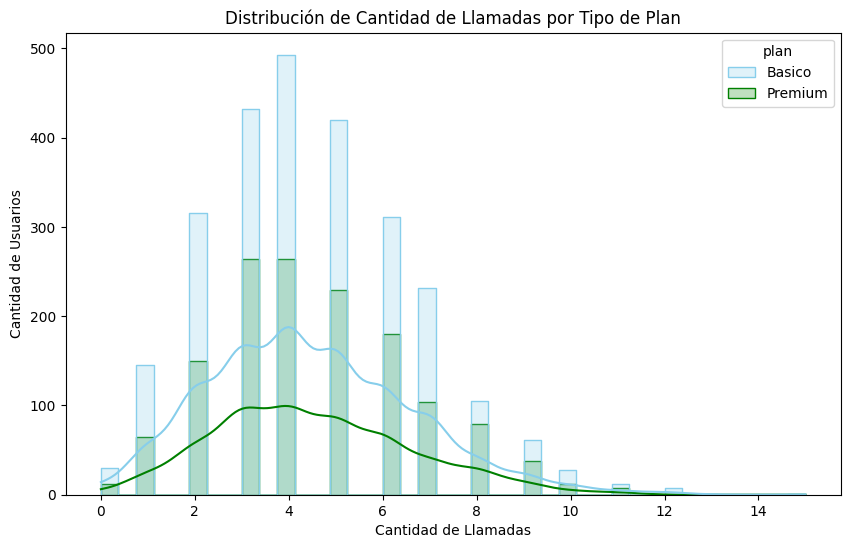

In [47]:

# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', element='step', palette=['skyblue', 'green'], kde=True)

# Títulos y etiquetas
plt.title('Distribución de Cantidad de Llamadas por Tipo de Plan')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Cantidad de Usuarios')
plt.show()



💡Insights: 
**Tipo de Distribución**:  Es una distribución Aproximadamente Simétrica. A diferencia de los mensajes, aquí no hay un pico exagerado en el cero; la mayoría de los usuarios se concentra en un rango "normal" de llamadas, lo que indica un hábito de consumo más constante.

Comparación por Plan:
-Plan Básico (Azul): Muestra una concentración muy alta de usuarios en el centro de la gráfica. Sus usuarios tienen un comportamiento muy predecible.

-Plan Premium (Verde): La curva es más baja y aplanada, lo que significa que hay más variedad: tenemos usuarios Premium que llaman muy poco y otros que llaman muchísimo más que el promedio del plan básico.

Conclusión: Las llamadas parecen ser el servicio principal de los usuarios. No hay una diferencia drástica en la forma de la distribución entre planes, pero los usuarios Premium tienen un rango de uso más amplio y flexible.

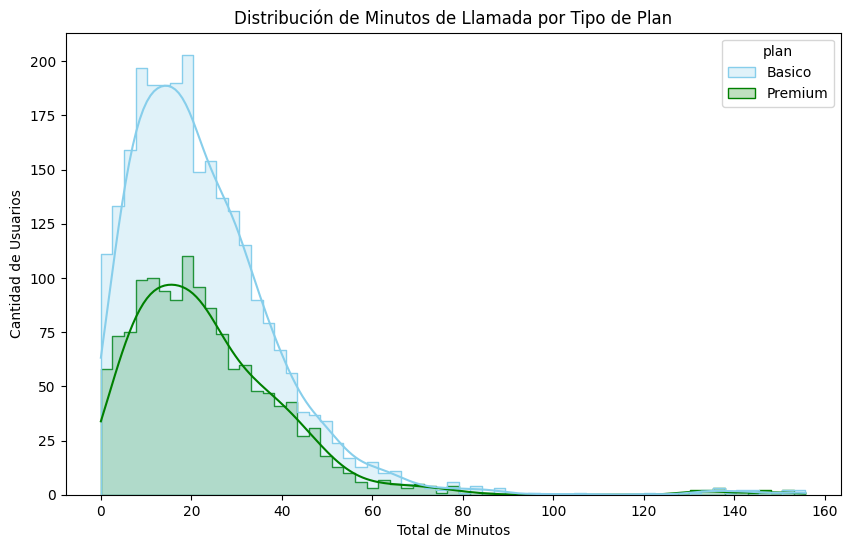

In [48]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', element='step', palette=['skyblue', 'green'], kde=True)

# Títulos y etiquetas
plt.title('Distribución de Minutos de Llamada por Tipo de Plan')
plt.xlabel('Total de Minutos')
plt.ylabel('Cantidad de Usuarios')
plt.show()


💡Insights: 
**Tipo de Distribución**: Presenta una distribución Aproximadamente Simétrica. La mayoría de los usuarios se concentra en un consumo medio.

Comparación por Plan:

-Plan Básico (Azul): Tiene una campana muy alta y estrecha. Esto sugiere que sus usuarios cuidan mucho sus minutos para no pasarse de su límite o presupuesto.

-Plan Premium (Verde): La campana es más ancha y baja. Esto demuestra que los usuarios Premium tienen un comportamiento más variado; algunos hablan poco, pero otros se sienten con la libertad de realizar llamadas mucho más largas.

Conclusión: El plan Premium ofrece una flexibilidad que el plan Básico no tiene. Los usuarios Premium no parecen estar limitados por los minutos, lo que genera una mayor dispersión en los datos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

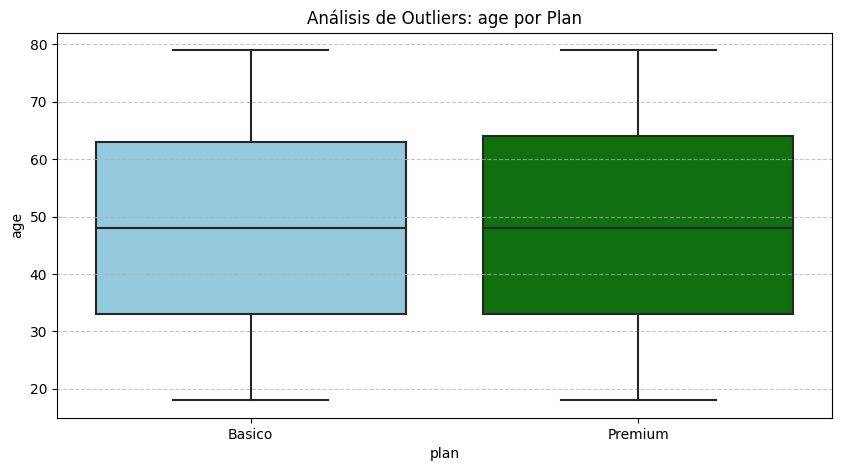

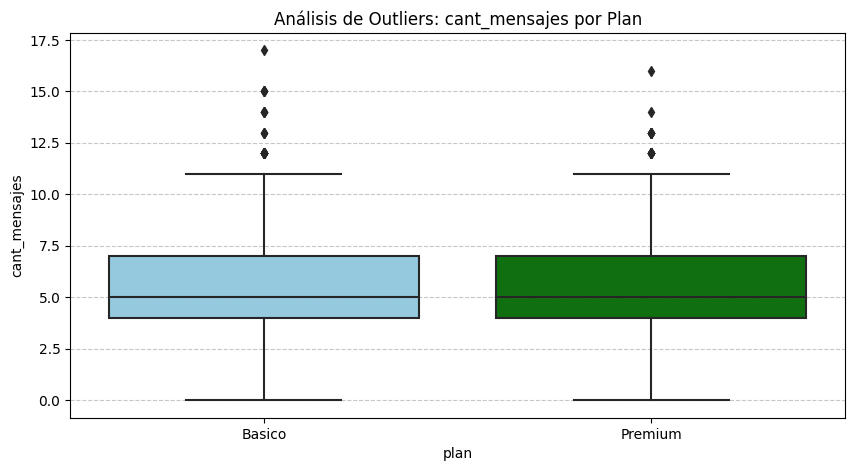

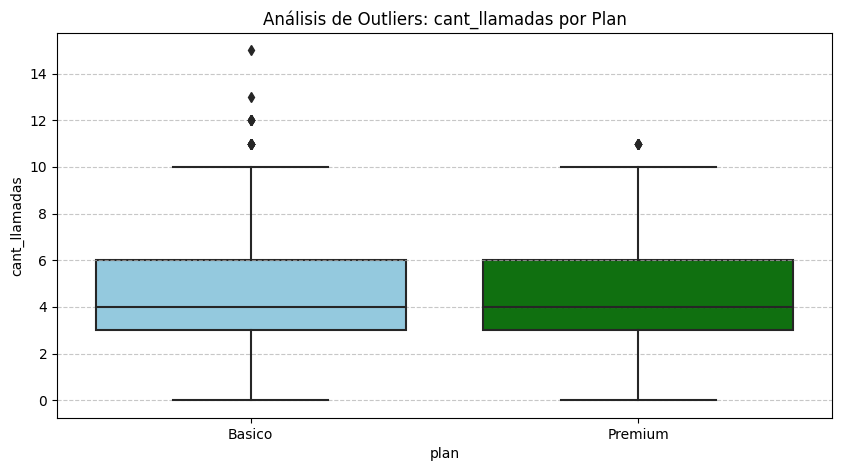

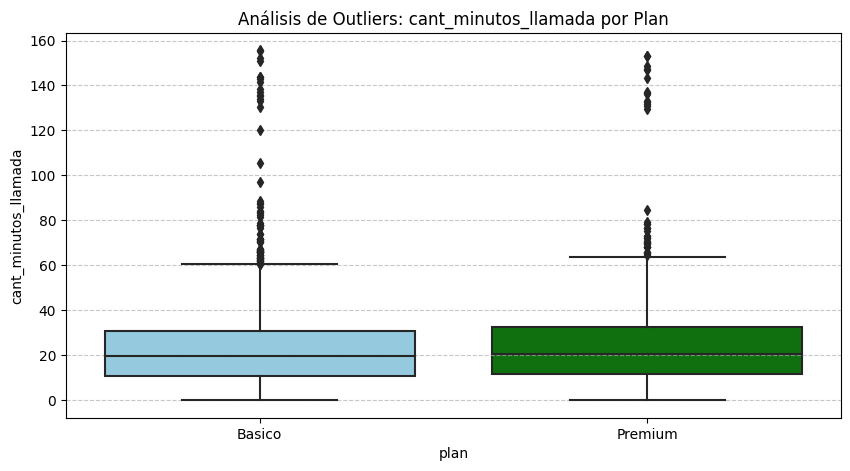

In [49]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=user_profile, x='plan', y=col, palette=['skyblue', 'green'])
    
    # Añadimos títulos dinámicos
    plt.title(f'Análisis de Outliers: {col} por Plan')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

💡Insights: 
-Age: No presenta outliers. Los bigotes del gráfico cubren todo el rango de datos. Esto indica que las edades están bien distribuidas entre los 18 y 80 años, sin valores imposibles o extraños.

-cant_mensajes: Presenta outliers significativos. Se observan varios puntos por encima del bigote superior en ambos planes. Hay usuarios intensos que envían más de 120 mensajes, lo cual es muy superior al promedio de 30-50.

-cant_llamadas: Presenta algunos outliers. Aunque la distribución es más simétrica, existen usuarios en ambos planes que realizan una cantidad de llamadas inusualmente alta (superando las 12-14 llamadas en el periodo registrado).

-cant_minutos_llamada: Presenta outliers moderados. Especialmente en el Plan Básico, se ven usuarios que hablan mucho más que el resto de su grupo (superando los 100-120 minutos), acercándose al comportamiento de un usuario Premium.

In [56]:
# Calcular límites con el método IQR
columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

print("Límites de detección de Outliers (Método IQR):")
print("-" * 45)

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

lim_sup = Q3 + 1.5 * IQR
lim_inf = max(0, Q1 - 1.5 * IQR)

# 2. Comparación con el Máximo Real
max_real = user_profile[col].max()
    
print(f"Variable: {col}")
print(f"  > Rango Normal: {lim_inf:.2f} a {lim_sup:.2f}")
print(f"  > Valor Máximo Real: {max_real:.2f}")


Límites de detección de Outliers (Método IQR):
---------------------------------------------
Variable: cant_minutos_llamada
  > Rango Normal: 0.00 a 61.87
  > Valor Máximo Real: 155.69


In [57]:

# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
print("\n--- ESTADÍSTICAS PARA COMPARACIÓN FINAL ---")
display(user_profile[columnas_limites].describe().loc[['mean', '50%', 'max']])
user_profile[columnas_limites].describe()




--- ESTADÍSTICAS PARA COMPARACIÓN FINAL ---


,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
mean,48.136,5.523,4.477,23.311225
50%,48.000,5.000,4.000,19.780000
max,79.000,17.000,15.000,155.690000


,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000,4000.000000
mean,48.136000,5.523000,4.477000,23.311225
std,17.689919,2.359738,2.145139,18.169564
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.107500
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.412500
max,79.000000,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: **Mantener**. El límite teórico es de unos 11-12 mensajes, pero hay usuarios que llegan a 17. Es una diferencia pequeña y representa a usuarios activos que simplemente usan más el servicio. No son errores, son clientes reales.

-cant_llamadas: **Mantener** Al igual que los mensajes, el máximo (15) no está absurdamente lejos del límite (10.5). Es un comportamiento normal, hay días o personas que llaman más que el promedio.

-cant_minutos_llamada: **Mantener** Aquí es donde está la mayor diferencia: el límite es ~62 minutos pero hay alguien con 155.69. Si lo borro, ignoro a los usuarios que generan los mayores ingresos por excedentes.

Decisión Final: He decidido mantener los outliers en las tres variables de consumo (cant_mensajes, cant_llamadas, cant_minutos_llamada). Aunque algunos usuarios superan los límites del método IQR (especialmente en minutos de llamada con un máximo de 155.69 vs un límite de ~62), estos datos representan comportamientos reales de consumo intenso.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [58]:
# Crear columna grupo_uso
def definir_segmento(row):
    llamadas = row['cant_llamadas']
    mensajes = row['cant_mensajes']
    
    if llamadas < 5 and mensajes < 5:
        return 'Bajo uso'
    elif llamadas < 10 and mensajes < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(definir_segmento, axis=1)

In [60]:

# verificar cambios
print("Primeros registros con la nueva segmentación:")
user_profile.head()


Primeros registros con la nueva segmentación:


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [61]:
# Crear columna grupo_edad
def segmentar_edad(edad):
    if edad < 30:
        return 'Joven'
    elif edad <= 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

# Creamos la columna grupo_edad
user_profile['grupo_edad'] = user_profile['age'].apply(segmentar_edad)

In [62]:
# verificar cambios
print("Visualización de las nuevas segmentaciones (Uso y Edad):")
display(user_profile.head())


Visualización de las nuevas segmentaciones (Uso y Edad):


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

Text(0, 0.5, 'Cantidad de Usuarios')

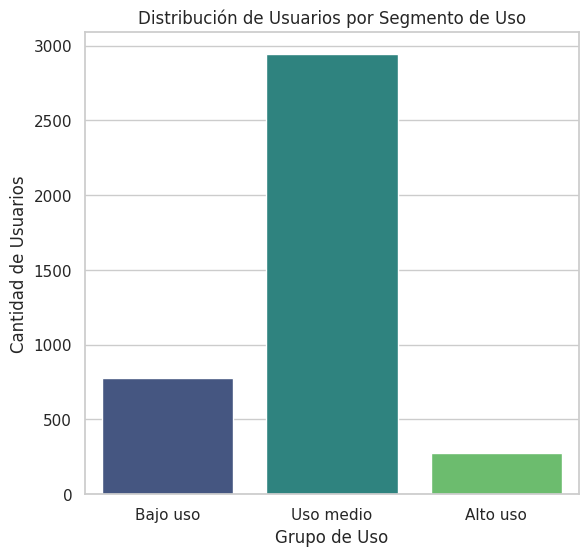

In [63]:
# Visualización de los segmentos por uso
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))

# 1. Visualización de los segmentos por uso
plt.subplot(1, 2, 1) # Primer gráfico (izquierda)
sns.countplot(data=user_profile, x='grupo_uso', palette='viridis', order=['Bajo uso', 'Uso medio', 'Alto uso'])
plt.title('Distribución de Usuarios por Segmento de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')

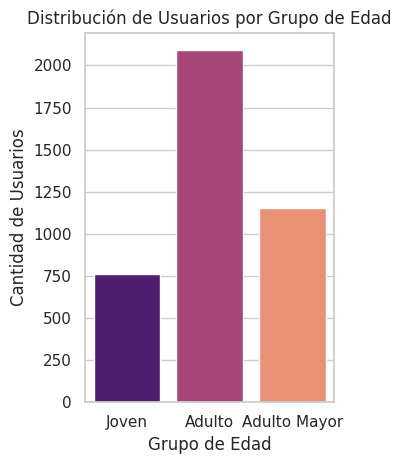

In [64]:

# Visualización de los segmentos por edad
plt.subplot(1, 2, 2) # Segundo gráfico (derecha)
sns.countplot(data=user_profile, x='grupo_edad', palette='magma', order=['Joven', 'Adulto', 'Adulto Mayor'])
plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')

plt.tight_layout() # Ajusta el espacio entre gráficos
plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
**- ¿Qué problemas tenían originalmemte los datos?**

Al inicio, la base de datos tenía "datos" que podía engañarnos

**- ¿Qué porcentaje, o cantidad de filas, de esa columna representaban?**
-Valores Nulos (NaN): En la columna city, aproximadamente el 10% de los datos (400 filas) estaban vacíos.

-Datos Faltantes en Churn: La columna churn_date estaba casi vacía, lo cual es bueno, porque significa que la mayoría de los clientes siguen activos y no han cancelado el servicio.

-Inconsistencias: Nombres con formatos distintos y edades que necesitaban ser agrupadas para entender mejor al cliente.

**- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?**

Dividimos a los usuarios en dos grandes categorías:

-Por Uso: La gran mayoría (más del 70%) está en Uso Medio. Los de Bajo Uso son un grupo considerable, mientras que el Alto Uso es una minoría selecta.

-Por Edad: Cliente principal es el Adulto (30-60 años) y el Adulto Mayor (>60). Los jóvenes son el grupo más pequeño. Esto indica que ConnectaTel es una empresa percibida como confiable para perfiles maduros.


**- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?**
Los adultos en el segmento Alto Uso.
tienen un consumo estable, capacidad de pago y son los que más mensajes y minutos consumen, lo que genera ingresos constantes.

**- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?**
Encontramos Power Users que hablan hasta 155 minutos, cuando el promedio es de apenas 23.

Implicación: Si están en el Plan Básico, están pagando mucho en excedentes. Si están en el Premium, son clientes que realmente aprovechan el valor del plan y son difíciles de perder.

**- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?**
Identificar a los usuarios de "Alto Uso" que están en el Plan Básico y ofréceles pasar al Premium. A ellos les convendrá por precio y a la empresa le asegura una renta mensual más alta.



### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
-Datos faltantes: La columna city tenía un 10% de vacíos y la fecha de cancelación (churn_date) estaba casi limpia (lo cual indica que los clientes siguen activos).

-Valores extremos: Usuarios con consumos muy altos en minutos y mensajes que se salían del promedio normal.

🔍 **Segmentos por Edad**
-Dominio Adulto: La gran mayoría de los clientes son Adultos (30-60 años) y Adultos Mayores (+60).

-Baja presencia joven: El grupo de menores de 30 años es el más pequeño de la empresa.


📊 **Segmentos por Nivel de Uso**
-Uso Medio es la norma: Casi todos los usuarios tienen un consumo moderado y predecible.

-Power Users: Existe un grupo pequeño de "Alto uso" que consume el triple que el usuario promedio.


➡️ Esto sugiere que ...base de clientes es madura y estable. No buscan aplicaciones modernas, sino comunicación confiable (llamadas). Los usuarios de "Alto uso" en el plan Básico son los que más dinero dejan por cobro de excedentes.


💡 **Recomendaciones**
-Plan Familiar: Crear promociones para los adultos mayores.

-Migración a Premium: Invitar a los usuarios de "Alto uso" del plan Básico a pasarse al Premium para que sientan que ahorran, asegurando a la empresa una renta fija más alta.

-Captar Jóvenes: Diseñar un plan con más beneficios en mensajes para atraer al segmento menor de 30 años.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`